# Neurotransmission model
---
In this notebook we calibrate a compartmental model of neurotransmission dynamics. We first illustrate the model on synthetic data, and then calibrate it to a set of five *drosophila* synaptic current measurements using neural networks. The trained networks are stored in the `data` folder, and are used for evaluation here, but the neural networks can also be re-trained using the code in this notebook.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import torch
import xarray as xr

from torchaudio.functional import convolve
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch

# Local imports
import sys
import os
from os.path import dirname as up
from dantro._import_tools import import_module_from_path
root = up(os.path.dirname(os.getcwd()))
sys.path.append(root)
include = import_module_from_path(mod_path=root, mod_str="include")
model_plots = import_module_from_path(mod_path=root, mod_str="model_plots")
from include import neural_net, colors

# Model-specific imports
from model import impulse_function, Compartments, solve_ODE

# Use a custom style sheet and set the page width for best Latex integration
plt.style.use('model_plots.plot_style')
page_width = 6.47453
%matplotlib inline

## Define the ODE model
The ODE model is defined in the `model.py` file contained alongside this notebook; we illustrate the solver here using time-dependent fusion and unpriming rates $k_F(t)$ and $k_U(t)$:

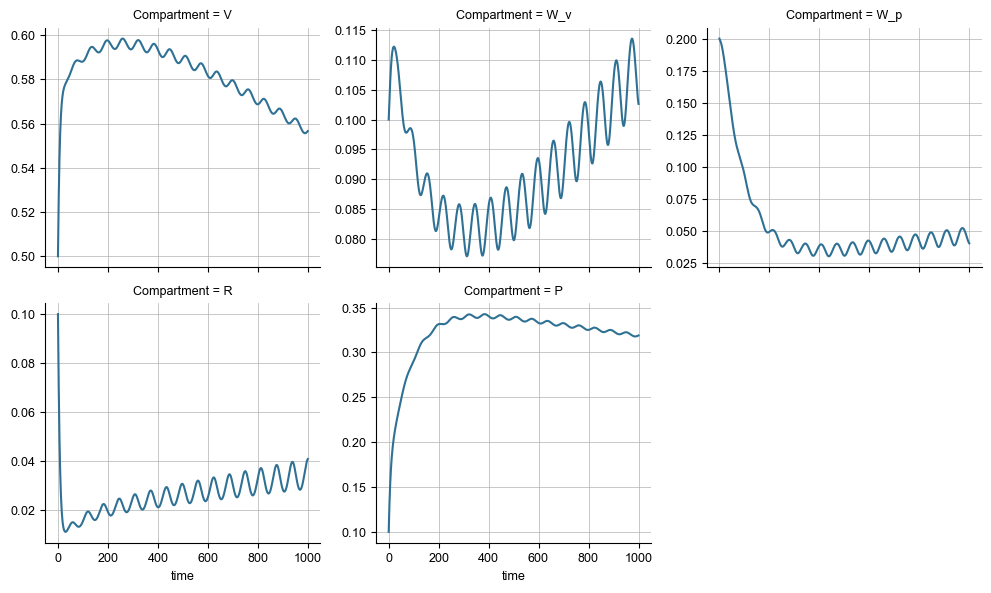

In [4]:
# Define an initial state
init_state = torch.tensor([0.5, 0.1, 0.2, 0.1, 0.1])

# Number of steps and time differential for the Euler solver
num_steps = 1000
dt = 0.1

# Run the solver. k_F and k_U need to be time-dependent
X = solve_ODE(init_state=init_state,
              k_R = 0.1,
              k_F = 0.2 * torch.sin(torch.arange(0, num_steps, dt)) + 0.15,
              k_U= 1.0 * torch.exp(-0.01*torch.arange(0, num_steps, dt)),
              g_V=0.04,
              g_P = 0.1,
              num_steps=num_steps,
              dt=dt)

# Plot using the handy xarray package
X = xr.DataArray(data=X, dims=['time', 'Compartment'], coords={'Compartment': [e.name for e in Compartments]})
X.plot(col='Compartment', sharey=False, col_wrap=3)

## Load animal data
Now, we turn to calibrating this model to data. First, we load the current data, which has 3000 time steps (spanning about 1 second of data) and is animal-specific; data is stored in the `data` folder:

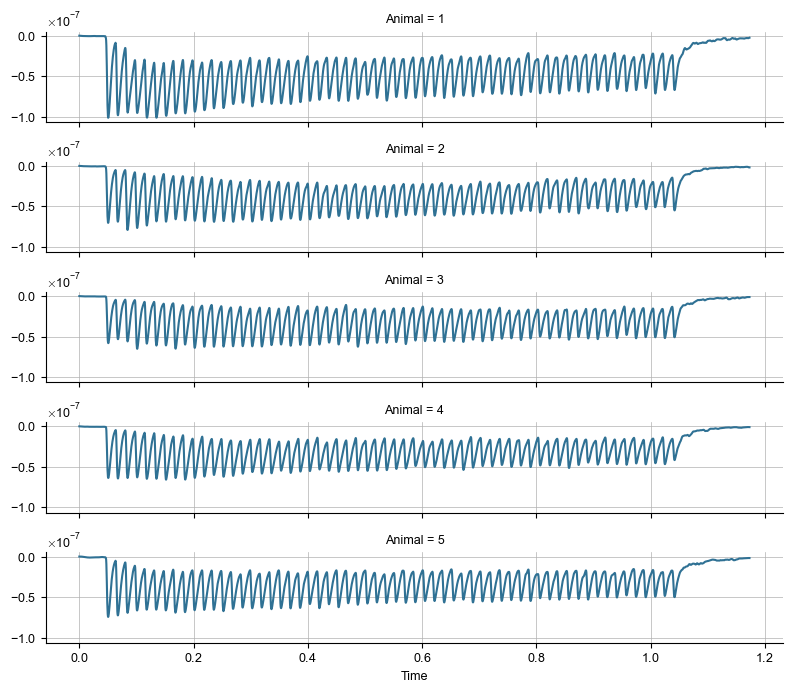

In [5]:
currents = xr.load_dataarray("../../data/Neurotransmission/current_data.nc")
currents.plot(row='Animal', figsize=(8, 7))

The impulse function is used to calculate the current via $$C(t) = N (\dot{F} \star g),$$ where $g$ is the following impulse function:

[None, Text(0.5, 0, 'ms'), Text(0, 0.5, 'nA')]

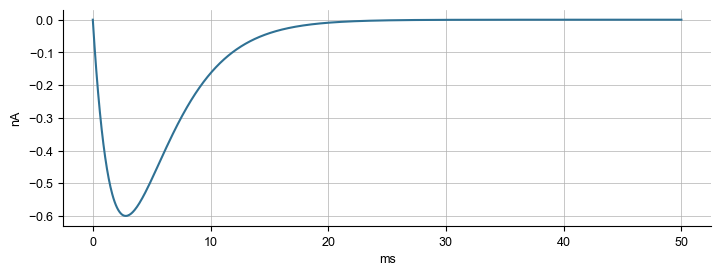

In [6]:
fig, ax = plt.subplots(figsize=(page_width, page_width/3))
ax.plot(torch.linspace(0, 50, 1000), impulse_function(torch.linspace(0, 0.05, 1000)) * 10**9)
ax.set(xscale='linear', xlabel='ms', ylabel='nA')

## Neural parameter calibration
We reserve one animal current time series as a test set, as well as the second half of each time series as test set. One further dataset is used to validate the model architecture.

We couple two neural networks: one for the constant parameters $(g_V, g_P, V_0, P_0, W_{V, 0}, W_{P, 0}, R_0)$, and one for the time-dependent parameters $k_F(t)$ and $k_U(t)$. Note that $R + V + W_V = const$, as is $R + P + W_P$. Note that all outputs must be positive.

In [7]:
# Calculate the impulse function and stack the currents
times = torch.from_numpy(currents.Time.data).float()
impulse_func_data = impulse_function(times).float()
current_data = torch.from_numpy(currents.data).float()
dt = times.diff().mean()

# To train, we only use a subset of the current data (first 0.6 s)
t0, t1 = 0, 1500 #1534

# Scale the current to avoid small losses
mu, var = current_data.mean(), current_data.std()
current_scaled = (current_data - mu) / var

# Training data are the first four datasets, using only the first 1500 frames.
# Test data is the remaining data within each training dataset
training_data = current_scaled[:-1, t0:t1]

# The validation dataset is the entire fifth current dataset
validation_data = current_scaled[[-1]]

impulse_func_data.shape, training_data.shape, dt

(torch.Size([3000]), torch.Size([4, 1500]), tensor(0.0004))

In [8]:
# Initialise two coupled neural networks
NN_const = neural_net.FeedForwardNN(
    input_size = training_data.shape[1], # Entire training time series as input
    output_size = 9, # Number of constant parameters to learn: g_P, g_V, k_R, N, and initial state V_0, P_0, W_V0, W_P0, R_0
    num_layers = 3,
    nodes_per_layer={"default": 6},
    activation_funcs={"default": "softplus"},
    biases={"default": [-1, 1]}
)

# RNN for time dependent parameters
NN_time_dep = neural_net.RNN(
    input_size=1, # A single time series point as input
    output_size=2,
    num_layers=3,
    latent_dim=1,
    nodes_per_layer={"default": 6},
    activation_funcs={"default": "softplus"},
    latent_activation_func='linear',
    biases={"default": [-1, 1]}
)

# Coupled optimiser: the optimiser trains both networks simultaneously
opt = torch.optim.Adam(list(NN_const.parameters()) + list(NN_time_dep.parameters()), lr=1e-3)
opt.zero_grad()

# Store the loss
loss_ts = []

We load the pre-trained networks; alternatively, to train, run the code block below the next for a given number of epochs.

In [9]:
NN_time_dep.load_state_dict(torch.load("../../data/Neurotransmission/NN_time_dep.pt", weights_only=True))
NN_time_dep.eval()

NN_const.load_state_dict(torch.load("../../data/Neurotransmission/NN_const.pt", weights_only=True))
NN_const.eval()

opt.load_state_dict(torch.load("../../data/Neurotransmission/opt.pt", weights_only=True))

In [10]:
batch_size = 4
for epoch in (pbar := tqdm.trange(0)):
    epoch_loss = []
    loss = torch.tensor(0.0, requires_grad=True)

    for batch, dset in enumerate(training_data):

        # Generate constant parameters
        g_P, g_V, k_R, V_0, P_0, W_V0, W_P0, R_0, N = NN_const(dset)

        # Predicted time-dependent parameters
        time_dep_params = NN_time_dep(dset.reshape(-1, 1))

        # Solve the ODE
        Y_pred = solve_ODE(
            init_state=torch.stack([V_0, W_V0, W_P0, R_0, P_0]),
            k_R = k_R, g_P=g_P, g_V=g_V,
            k_F = time_dep_params[:, 0],
            k_U = time_dep_params[:, 1],
            num_steps=dset.shape[0], dt=dt)

        # Calculate the predicted current
        C_pred = convolve(
            torch.nn.functional.pad(Y_pred[:-1, Compartments.R] * time_dep_params[:, 0],
                                    (t0, len(impulse_func_data)-t1)), N*impulse_func_data)[t0:t1]*dt

        # Calculate the loss
        loss = loss + torch.nn.functional.mse_loss((C_pred - mu)/var, dset)

        # Backprop
        if (batch + 1) % batch_size == 0 or batch == len(training_data) - 1:
            loss.backward()
            opt.step()
            opt.zero_grad()
            epoch_loss.append(loss.detach().numpy())
            loss = torch.tensor(0.0, requires_grad=True)

        # Reset the hidden state of the RNN
        NN_time_dep.reset_hidden_state()

    loss_ts.append(np.mean(epoch_loss))
    pbar.set_description(f"Loss: {loss_ts [-1]:.6g}")

0it [00:00, ?it/s]


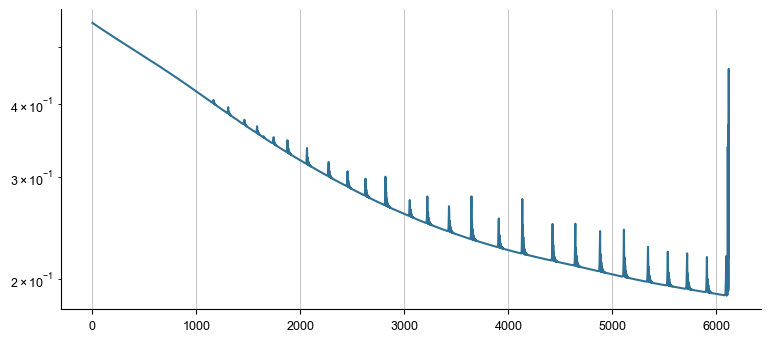

In [308]:
plt.plot(loss_ts)
plt.yscale('log')

In [11]:
# Once trained, make a prediction
time_dep_params = []
NN_time_dep.reset_hidden_state()
with torch.no_grad():
    const_params = torch.stack([NN_const(dset) for dset in current_scaled[:, t0:t1]])
    for dset in current_scaled[:, t0:]:
        time_dep_params.append(NN_time_dep(dset.reshape(-1, 1)))
        NN_time_dep.reset_hidden_state()
    time_dep_params = torch.stack(time_dep_params)

# Generate an ODE time series with each prediction
Y_pred = []
for idx in range(len(current_scaled)):
    g_P, g_V, k_R, V_0, P_0, W_V0, W_P0, R_0, N = const_params[idx]
    Y_pred.append(
        solve_ODE(
            init_state=torch.stack([V_0, W_V0, W_P0, R_0, P_0]),
            k_R = k_R, g_P=g_P, g_V=g_V,
            k_F = time_dep_params[idx][:, 0],
            k_U = time_dep_params[idx][:, 1],
            num_steps=current_scaled.shape[1], dt=dt)
    )
Y_pred = torch.stack(Y_pred)

In [12]:
C_pred = torch.stack([
    convolve(torch.nn.functional.pad(Y_pred[idx][:, Compartments.R][:-1] * time_dep_params[idx][:, 0], (t0, len(impulse_func_data)-t1)), const_params[idx][-1]*impulse_func_data)[0:current_scaled.shape[1]]*dt for idx in range(5)])

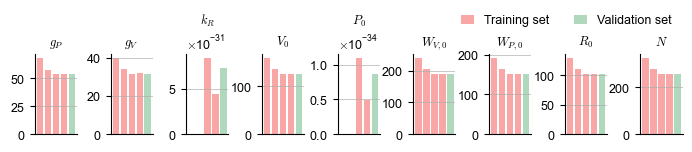

In [13]:
fig, axs = plt.subplots(ncols=9, figsize=(page_width, 0.8), gridspec_kw={'wspace': 0.8})
for idx, param in enumerate(['$g_P$', '$g_V$', '$k_R$', '$V_0$', '$P_0$', '$W_{V,0}$', '$W_{P,0}$', '$R_0$', '$N$']):
    for i in range(5):
        axs[idx].bar([i], const_params.T[idx, i], color=colors['c_pink'] if i < 4 else colors['c_lightgreen'] if i == 4 else colors['c_lightblue'],
                     label='Training set' if i ==0 and idx == 0 else 'Validation set' if i ==4 and idx ==0 else None)
    axs[idx].set_title(param)
    axs[idx].tick_params(axis='x', length=0)
    axs[idx].set_xticks([])
fig.legend(ncols=5, bbox_to_anchor=(1, 1.2), loc='lower right')

Plot a single panel of the fusion rate $k_F(t)$

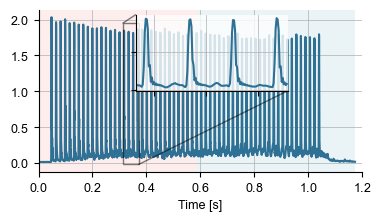

In [15]:
fig, ax = plt.subplots(figsize=(page_width/2, page_width/4))
ax.axvspan(t0 * dt, t1 * dt, color=colors['c_pink'], zorder=-1, alpha=0.2, lw=0)
ax.axvspan(t1 * dt, times[-1], color=colors['c_lightblue'], zorder=-1, alpha=0.2, lw=0)
ax.patch.set(alpha=0.0)
ax.set(xlim=(0, 1.2))
_t1, _t2 = 800, 950 # k_F zoom window times
a_idx = 2 # Animal to plot
ax.plot(times[t0:], time_dep_params[a_idx, :, 0])

# Zoom window for k_F
axins1 = ax.inset_axes(
    [0.3, 0.5, 0.47, 0.47], xlim=(times[_t1], times[_t2]),
    xticklabels=[], yticklabels=[])
axins1.set_facecolor('white')
axins1.patch.set_alpha(0.8)
axins1.plot(times[_t1:_t2], time_dep_params[a_idx, _t1:_t2, 0])
ind = ax.indicate_inset_zoom(axins1, edgecolor="black")

ax.set(xlabel='Time [s]')
fig.patch.set_alpha(0)

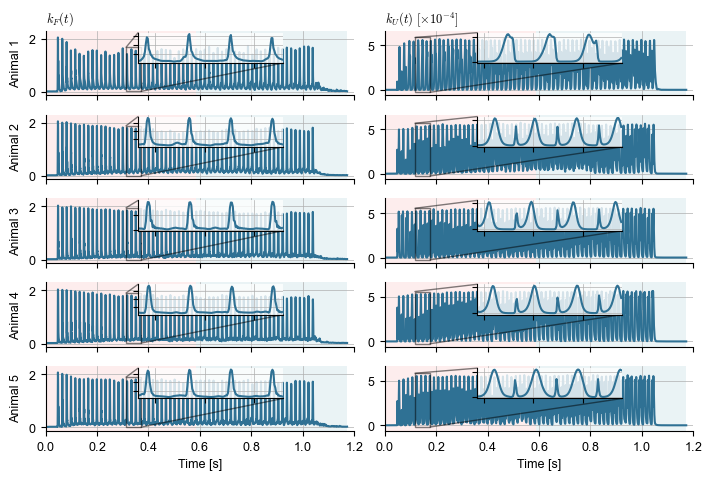

In [16]:
fig, axs = plt.subplots(figsize=(page_width, 4), nrows=len(current_data), ncols=2, sharey='col',sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0.3})

# Mark the training and test parts
for ax in axs.flatten():
    ax.axvspan(t0 * dt, t1 * dt, color=colors['c_pink'], zorder=-1, alpha=0.2, lw=0)
    ax.axvspan(t1 * dt, times[-1], color=colors['c_lightblue'], zorder=-1, alpha=0.2, lw=0)
    ax.patch.set(alpha=0.0)
    ax.set(xlim=(0, 1.2))

# Define the zoom window times
_t1, _t2 = 800, 950 # k_F
_t3, _t4 = 300, 450 # k_U

# Plot the time-dependent parameters for each animal with a zoom window
for a_idx in range(5):

    # Plot the full parameters
    axs[a_idx, 0].plot(times[t0:], time_dep_params[a_idx, :, 0])
    axs[a_idx, 1].plot(times[t0:], 1e5*time_dep_params[a_idx, :, 1])
    axs[a_idx, 0].set_ylabel(f'Animal {a_idx+1}')
    axs[a_idx, 1].ticklabel_format(axis='y', scilimits=(0, 0))

    # Zoom window for k_F
    axins1 = axs[a_idx, 0].inset_axes(
        [0.3, 0.5, 0.47, 0.47], xlim=(times[_t1], times[_t2]),
        xticklabels=[], yticklabels=[])
    axins1.set_facecolor('white')
    axins1.patch.set_alpha(0.8)
    axins1.plot(times[_t1:_t2], time_dep_params[a_idx, _t1:_t2, 0])
    ind = axs[a_idx, 0].indicate_inset_zoom(axins1, edgecolor="black")

    # Zoom window for k_U
    axins2 = axs[a_idx, 1].inset_axes(
        [0.3, 0.5, 0.47, 0.47], xlim=(times[_t3], times[_t4]),
        xticklabels=[], yticklabels=[])
    axins2.set_facecolor('white')
    axins2.patch.set_alpha(0.8)
    axins2.plot(times[_t3:_t4], 1e5*time_dep_params[a_idx, _t3:_t4, 1])
    axs[a_idx, 1].indicate_inset_zoom(axins2, edgecolor="black")

for i in range(2):
    axs[-1, i].set(xlabel='Time [s]')
axs[0, 0].set_title(r'$k_F(t)$', ha='left', x=0)
axs[0, 1].set_title(r'$k_U(t) \ [\times 10^{-4}]$', ha='left', x=0)
fig.patch.set_alpha(0)
fig.subplots_adjust(wspace=0.15)

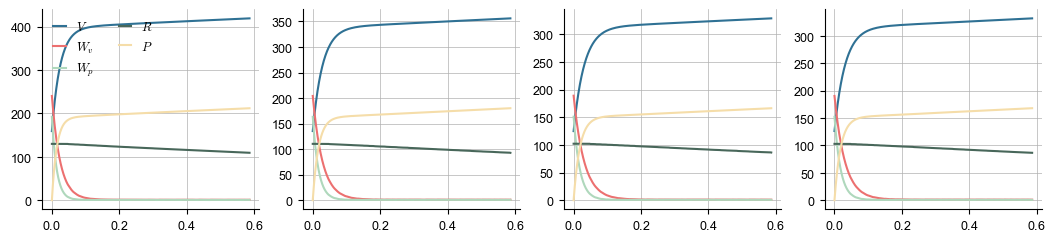

In [17]:
# Plot the system state
fig, axs = plt.subplots(ncols=4, figsize=(10, 2))
for idx in range(len(Y_pred)-1):
    axs[idx].plot(times[t0:t1], Y_pred[idx, t0:t1], label=[rf'${e.name}$' for e in Compartments])
axs[0].legend(ncols=2, handlelength=1, framealpha=0)

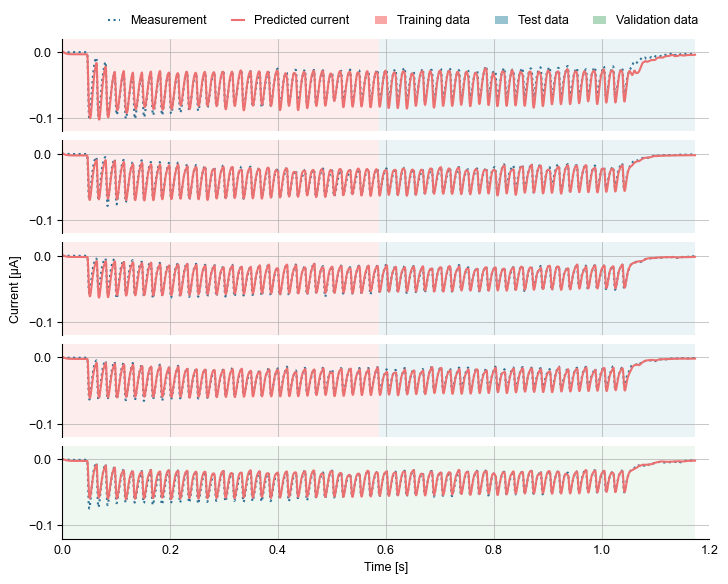

In [18]:
fig, axs = plt.subplots(nrows=5, figsize=(page_width, 5), sharex=True, sharey=True, gridspec_kw={'hspace': 0.1})

# Plot the results on each dataset
for idx in range(len(Y_pred)):
    l1 = axs[idx].plot(times, 1e6*current_data[idx], ls='dotted')
    l2 = axs[idx].plot(times, 1e6*C_pred[idx])

    # Mark the training data
    if idx < 4:
        h1 = axs[idx].axvspan(times[t0], times[t1], color=colors['c_pink'], alpha=0.2, zorder=-1, lw=0)
        h2 = axs[idx].axvspan(times[t1], times[-1], color=colors['c_lightblue'], alpha=0.2, zorder=-1, lw=0)
        axs[idx].spines['bottom'].set_visible(False)
        axs[idx].tick_params(axis='x', length=0)

    # Validation data
    elif idx == 4:
        h3 = axs[idx].axvspan(times[t0], times[-1], color=colors['c_lightgreen'], alpha=0.2, zorder=-1, lw=0)
        axs[idx].spines['bottom'].set_visible(False)
        axs[idx].tick_params(axis='x', length=0)

# Set axis limits and legends
axs[0].set(ylim=(-0.12, 0.02), xlim=(0, 1.2))
axs[0].set_yticks([-0.1, 0])
axs[2].set(ylabel='Current [µA]')
axs[-1].set(xlabel='Time [s]')
axs[-1].spines['bottom'].set_visible(True)

leg = fig.legend(handles=[l1[0], l2[0], h1, h2, h3], labels=['Measurement', 'Predicted current', 'Training data', 'Test data', 'Validation data'], ncols=5, bbox_to_anchor=(1, 1), loc='lower right')
for lh in leg.legend_handles:
    lh.set_alpha(1)

[Text(0.5, 0, 'Time [s]')]

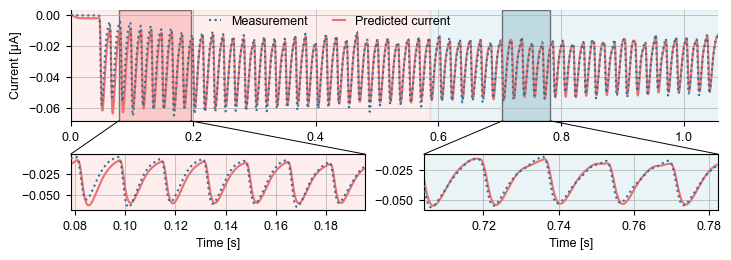

In [19]:
# Zoom in to a section of the time series of a certain animal
fig = plt.figure(figsize=(page_width, 2))
gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1], wspace=0.2, hspace=0.4)
animal_idx = 2

# Plot the full time series
ax1 = fig.add_subplot(gs[0, :])
xlim = (t0 * dt, times[-300])

# Define the zoom window
_t1, _t2 = 200, 500
_t3, _t4 = 1800, 2000

# Plot the full current (in units of nA)
ax1.plot(times, 1e6*current_data[animal_idx, :], ls='dotted', zorder=10, label='Measurement')
ax1.plot(times, 1e6*C_pred[animal_idx], label='Predicted current')

ax1.axvspan(t0 * dt, t1 * dt, color=colors['c_pink'], zorder=-1, alpha=0.2)
ax1.axvspan(t1 * dt, times[-300], color=colors['c_lightblue'], zorder=-1, alpha=0.2)
ax1.axvspan(times[_t1], times[_t2], color=colors['c_pink'], zorder=-1, alpha=0.5, ec='black', lw=1)
ax1.axvspan(times[_t3], times[_t4], color=colors['c_lightblue'], zorder=-1, alpha=0.5, ec='black', lw=1)
ax1.set(xlim=xlim, ylabel='Current [µA]')
ax1.legend(ncols=2, handlelength=1, bbox_to_anchor=(0.4, 1.05), loc='upper center')

# Zoom in to calibration
ax2 = fig.add_subplot(gs[1, :-1])
ax2.plot(times[_t1:_t2], 1e6*current_data[animal_idx, _t1:_t2], ls='dotted', zorder=10, label='Measurement')
ax2.plot(times[_t1:_t2], 1e6*C_pred[animal_idx, _t1:_t2], label='Predicted current')

v1 = ax2.axvspan(times[_t1], times[_t2], color=colors['c_pink'], zorder=-1, alpha=0.2)
ax2.set(xlim=(times[_t1], times[_t2]))
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)

# Zoom in to prediction
ax3 = fig.add_subplot(gs[1:, -1])
ax3.plot(times[_t3:_t4], 1e6*current_data[animal_idx, _t3:_t4], ls='dotted', zorder=10, label='Measurement')
ax3.plot(times[_t3:_t4], 1e6*C_pred[animal_idx, _t3:_t4], label='Predicted current')

ax3.axvspan(times[_t3], times[_t4], color=colors['c_lightblue'], zorder=-1, alpha=0.2)
ax3.set(xlim=(times[_t3], times[_t4]))
ax3.spines['top'].set_visible(True)
ax3.spines['right'].set_visible(True)

# Add connection lines
cp1 = ConnectionPatch(xyA=(times[_t1], ax1.get_ylim()[0]), xyB=(0, 1), axesA=ax1, axesB=ax2,
                      coordsA="data", coordsB="axes fraction", lw=0.7, ls="-")
cp2 = ConnectionPatch(xyA=(times[_t2], ax1.get_ylim()[0]), xyB=(1, 1), axesA=ax1, axesB=ax2,
                      coordsA="data", coordsB="axes fraction", lw=0.7, ls="-")
cp3 = ConnectionPatch(xyA=(times[_t3], ax1.get_ylim()[0]), xyB=(0, 1), axesA=ax1, axesB=ax3,
                      coordsA="data", coordsB="axes fraction", lw=0.7, ls="-")
cp4 = ConnectionPatch(xyA=(times[_t4], ax1.get_ylim()[0]), xyB=(1, 1), axesA=ax1, axesB=ax3,
                      coordsA="data", coordsB="axes fraction", lw=0.7, ls="-")
ax1.add_patch(cp1)
ax1.add_patch(cp2)
ax1.add_patch(cp3)
ax1.add_patch(cp4)

ax2.set(xlabel='Time [s]')
ax3.set(xlabel='Time [s]')